In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("darkgrid")
print("All libraries imported ✅")

All libraries imported ✅


In [4]:
df = pd.read_csv("../data/processed_data.csv", index_col='Date', parse_dates=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1466, 13)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA7', 'MA21', 'Daily_Return', 'Volatility', 'Price_Range', 'Momentum', 'RSI', 'Target']


,Close,High,Low,Open,Volume,MA7,MA21,Daily_Return,Volatility,Price_Range,Momentum,RSI,Target
Date,,,,,,,,,,,,,
2020-01-29,662.015503,668.524454,654.947287,659.420810,24746565,675.746033,682.510643,0.550371,0.932805,13.577167,-19.683472,33.110325,0
2020-01-30,645.866089,661.948423,644.188533,661.635285,22402689,669.984776,681.107878,-2.439431,1.135354,17.759891,-42.118164,28.126381,0
2020-01-31,631.506104,650.116002,629.515409,650.004137,34750310,662.207223,678.473825,-2.223369,1.172447,20.600593,-75.759216,25.145938,0
2020-02-03,619.807739,626.272016,609.764680,612.829051,30712290,653.173889,675.243298,-1.852455,1.145263,16.507337,-65.693787,24.072101,1
2020-02-04,638.104431,640.833267,625.310140,626.294289,25383901,647.093087,673.643479,2.951995,1.998541,15.523127,-48.090454,34.425462,1


In [5]:
# Features (X) — inputs to the model
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'MA7', 'MA21', 'Daily_Return',
                'Volatility', 'Price_Range', 'Momentum', 'RSI']

X = df[feature_cols]
y = df['Target']

print("Features shape :", X.shape)
print("Target shape   :", y.shape)
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nUp days   : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Down days : {(y==0).sum()} ({(1-y.mean())*100:.1f}%)")

Features shape : (1466, 12)
Target shape   : (1466,)

Target distribution:
Target
1    763
0    703
Name: count, dtype: int64

Up days   : 763 (52.0%)
Down days : 703 (48.0%)


In [6]:
# 80% train, 20% test — do NOT shuffle (time series data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nTrain date range: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test  date range: {X_test.index.min().date()}  to {X_test.index.max().date()}")

Training samples : 1172
Testing samples  : 294

Train date range: 2020-01-29 to 2024-10-23
Test  date range: 2024-10-24  to 2025-12-30


In [7]:
# StandardScaler makes all features have same scale
# (important for Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✅")
print(f"Mean of scaled training data: {X_train_scaled.mean():.4f} (should be ~0)")
print(f"Std  of scaled training data: {X_train_scaled.std():.4f}  (should be ~1)")

Features scaled ✅
Mean of scaled training data: -0.0000 (should be ~0)
Std  of scaled training data: 1.0000  (should be ~1)


In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Evaluation
lr_acc = accuracy_score(y_test, lr_pred)
print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"Accuracy : {lr_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Down (0)', 'Up (1)']))

LOGISTIC REGRESSION RESULTS
Accuracy : 46.94%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.44      0.25      0.32       146
      Up (1)       0.48      0.69      0.57       148

    accuracy                           0.47       294
   macro avg       0.46      0.47      0.44       294
weighted avg       0.46      0.47      0.44       294



In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_acc = accuracy_score(y_test, rf_pred)
print("=" * 45)
print("RANDOM FOREST RESULTS")
print("=" * 45)
print(f"Accuracy : {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Down (0)', 'Up (1)']))

RANDOM FOREST RESULTS
Accuracy : 51.70%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.52      0.36      0.43       146
      Up (1)       0.52      0.67      0.58       148

    accuracy                           0.52       294
   macro avg       0.52      0.52      0.50       294
weighted avg       0.52      0.52      0.51       294



In [10]:
print("=" * 45)
print("MODEL COMPARISON")
print("=" * 45)
print(f"Logistic Regression  : {lr_acc*100:.2f}%")
print(f"Random Forest        : {rf_acc*100:.2f}%")
print("-" * 45)

if rf_acc > lr_acc:
    print("Winner: Random Forest 🏆")
    best_model = rf_model
    best_pred  = rf_pred
    best_name  = "Random Forest"
else:
    print("Winner: Logistic Regression 🏆")
    best_model = lr_model
    best_pred  = lr_pred
    best_name  = "Logistic Regression"

print(f"\nBest model accuracy: {max(lr_acc, rf_acc)*100:.2f}%")

MODEL COMPARISON
Logistic Regression  : 46.94%
Random Forest        : 51.70%
---------------------------------------------
Winner: Random Forest 🏆

Best model accuracy: 51.70%


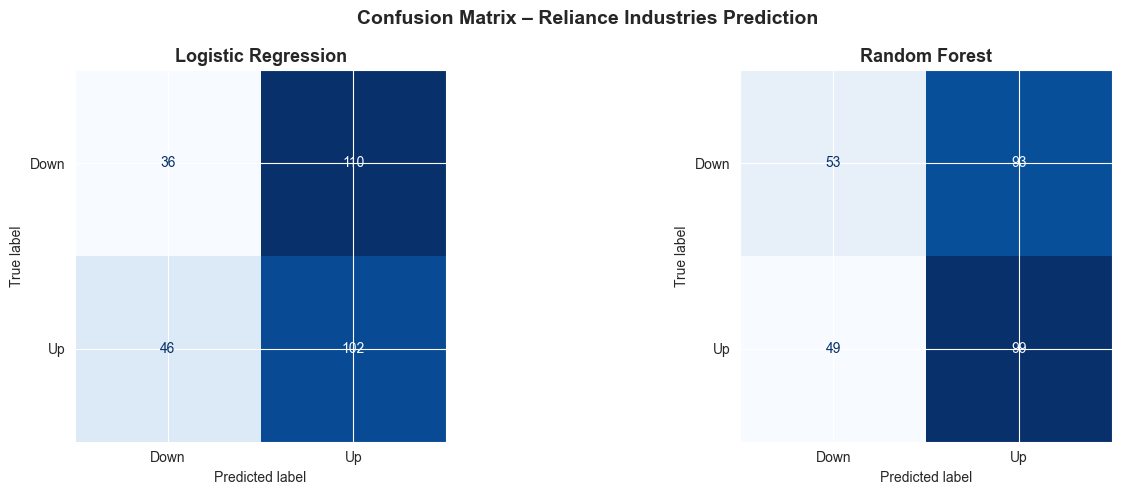

Confusion matrix saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes,
                           [lr_pred, rf_pred],
                           ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix – Reliance Industries Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/chart7_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

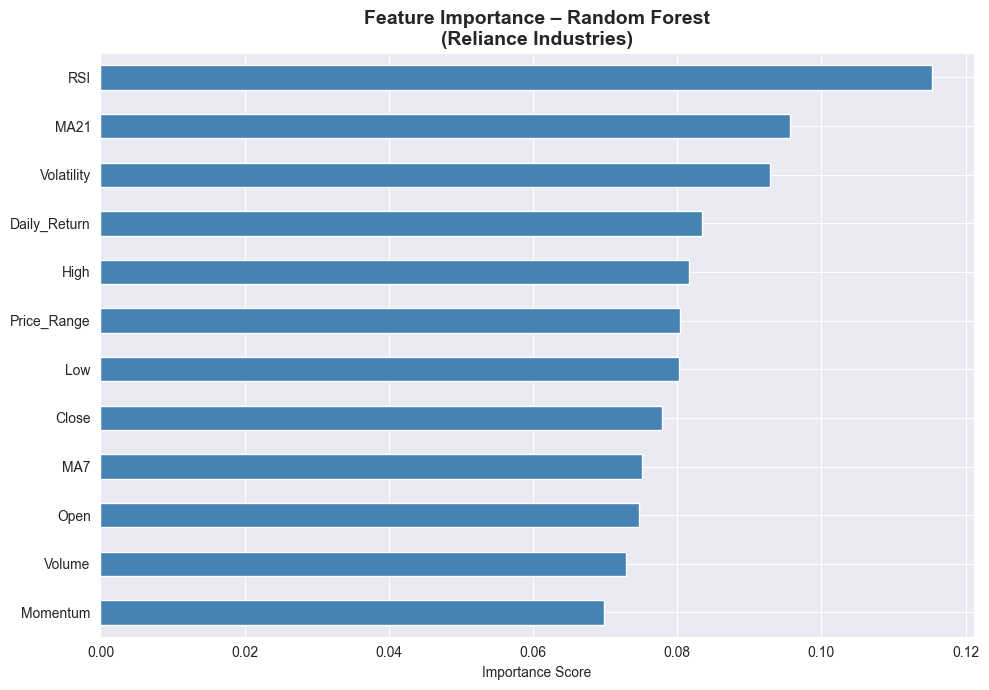


Top 3 most important features:
RSI           0.115354
MA21          0.095588
Volatility    0.092845
dtype: float64


In [12]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance – Random Forest\n(Reliance Industries)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/chart8_feature_importance.png', dpi=150)
plt.show()

print("\nTop 3 most important features:")
print(importance.sort_values(ascending=False).head(3))

In [13]:
# Save best model and scaler
joblib.dump(best_model, '../models/stock_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

print(f"✅ {best_name} saved to models/stock_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")

✅ Random Forest saved to models/stock_model.pkl
✅ Scaler saved to models/scaler.pkl


In [15]:
print("=" * 50)
print("PHASE 5 COMPLETE — MODEL TRAINING SUMMARY")
print("=" * 50)
print(f"Stock            : RELIANCE.NS")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Features used    : {len(feature_cols)}")
print(f"LR Accuracy      : {lr_acc*100:.2f}%")
print(f"RF Accuracy      : {rf_acc*100:.2f}%")
print(f"Best Model       : {best_name}")
print(f"Model saved      : models/stock_model.pkl")
print("=" * 50)

PHASE 5 COMPLETE — MODEL TRAINING SUMMARY
Stock            : RELIANCE.NS
Training samples : 1172
Testing samples  : 294
Features used    : 12
LR Accuracy      : 46.94%
RF Accuracy      : 51.70%
Best Model       : Random Forest
Model saved      : models/stock_model.pkl
